# 4.데이터분석_이변량_범주(숫자) vs 범주

## 4.1.환경준비

**1) 라이브러리 불러오기**

In [2]:
import pandas as pd
import numpy as np
import random as rd

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic      #mosaic plot!

import scipy.stats as spst

**1) 데이터 불러오기**
- 타이타닉 생존자 : titanic.csv  


In [3]:
titanic = pd.read_csv('data/titanic_train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
def extract_title(name):
    if 'Mr.' in name:
        return 'Mr'
    elif 'Mrs.' in name:
        return 'Mrs'
    elif 'Miss.' in name:
        return 'Miss'
    elif 'Master' in name:
        return 'Master'
    else:
        return 'Others'

# Title 열 추가
titanic['Title'] = titanic['Name'].apply(extract_title)

# 결과 확인
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Others
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


In [9]:
titanic['Title'].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Others     27
Name: count, dtype: int64

## 4.2.범주 --> 범주

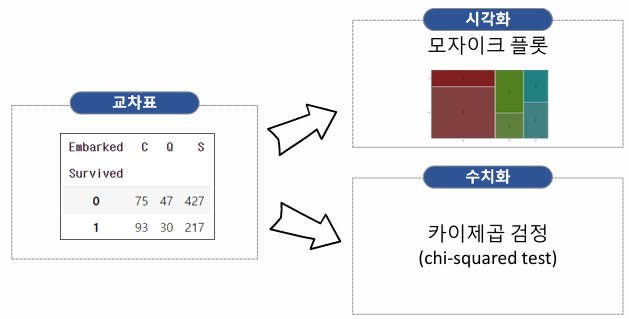

### 4.2.1. 교차표(pd.crosstab)

- 범주 vs 범주 를 비교하고 분석하기 위해서는 먼저 **교차표**를 만들어야 한다.

- pd.crosstab(행, 열)

In [6]:
pd.crosstab(titanic['Survived'], titanic['Sex'])

Sex,female,male
Survived,,
0,81,468
1,233,109


- `pd.crosstab(행, 열, normalize =   )`
    - normalize: 비율로 계산
    - 행 기준: 각 범주 내 분포를 분석할 때 유용
    - 열 기준: 변수 간 비교를 통해 특정 범주 내 다른 변수의 비율을 볼 때 유용


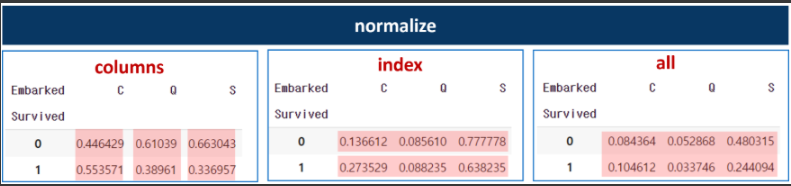

In [7]:
#  컬럼(열)을 기준으로 합했을 때
pd.crosstab(titanic['Survived'], titanic['Sex'], normalize = 'columns')

Sex,female,male
Survived,,
0,0.257962,0.811092
1,0.742038,0.188908


In [10]:
# 인덱스(행)을 기준으로 합했을 때
pd.crosstab(titanic['Survived'], titanic['Sex'], normalize = 'index')

Sex,female,male
Survived,,
0,0.147541,0.852459
1,0.681287,0.318713


In [11]:
pd.crosstab(titanic['Survived'], titanic['Sex'], normalize = 'all')

Sex,female,male
Survived,,
0,0.090909,0.525253
1,0.261504,0.122334


### 4.2.2. 시각화
- mosaic
- 100% Stacked Bar


1) Pclass --> Survived

- mosaic plot
    - `mosaic(dataframe, [ feature, target])`
    - 범주형 변수 간의 비율과 분포를 시각적으로 나타내는 그래프
    - 교차표의 형태를 그림으로 표현하며, 각 사각형의 크기와 길이는 데이터의 비율을 나타냄

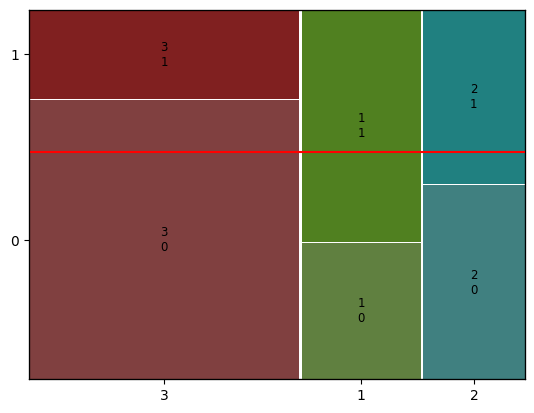

In [12]:
mosaic(titanic, ['Pclass', 'Survived'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-titanic['Survived'].mean(), color='r')    # 전체 

plt.show()
                

① X축 길이는 각 객실등급별 승객비율을 나타낸다.

② 그 중 3등급 객실에 대해서 보면, y축의 길이는, 3등급 객실 승객 중에서 사망, 생존 비율을 의미한다.

- 100% Stacked Bar
    - 먼저 crosstab으로 집계 : `pd.crosstab(feature, target, normalize = 'index')`
    - `.plot.bar(stacked = true)`
    - 전체 평균선 : `plt.axhline()`

Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363
------------------------------


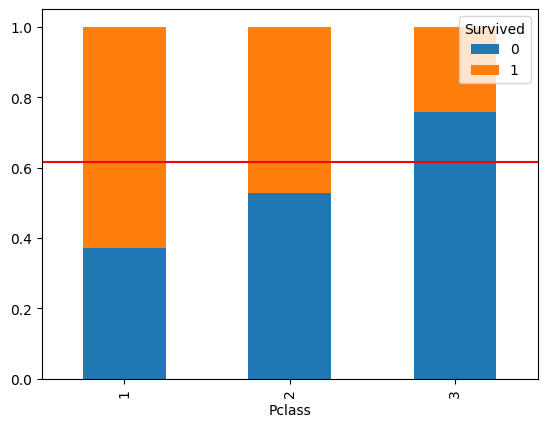

In [15]:
temp = pd.crosstab(titanic['Pclass'], titanic['Survived'], normalize='index')
print(temp)
print('-'*30)

temp.plot.bar(stacked=True)
plt.axhline(1-titanic['Survived'].mean(), color='r')
plt.show()

- 비율만 비교하므로 양에 대한 비교는 할 수 없다!

**<연습문제>**

- 아래 관계에 대해서 교차표와 시각화(mosaic)를 수행하고, feature와 target 간에 관계가 있는지 분석해 봅시다.


In [ ]:
titanic.head()

[문1] Sex --> Survived

In [17]:
pd.crosstab(titanic['Survived'], titanic['Sex'], normalize = 'columns')

Sex,female,male
Survived,,
0,0.257962,0.811092
1,0.742038,0.188908


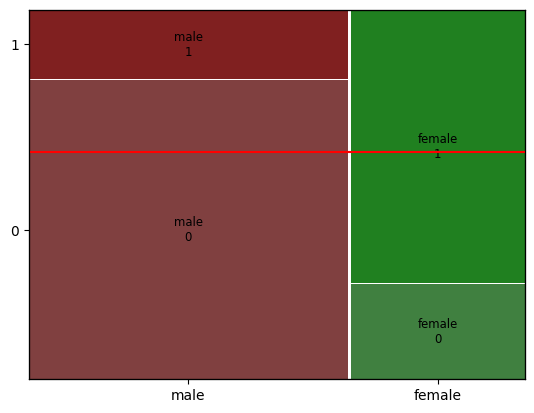

In [18]:
mosaic(titanic, ['Sex', 'Survived'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-titanic['Survived'].mean(), color='r')    # 전체 

plt.show()
                

Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908
------------------------------


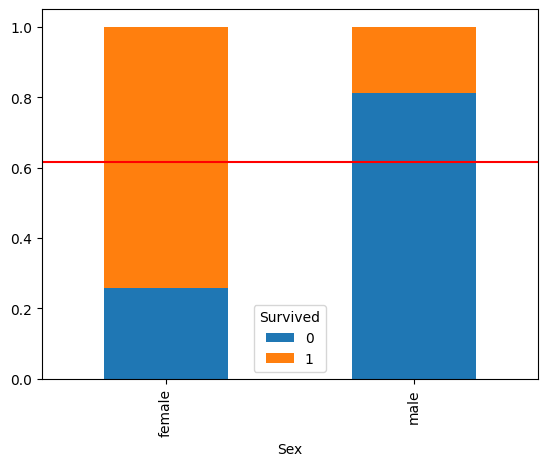

In [20]:
temp = pd.crosstab(titanic['Sex'], titanic['Survived'], normalize='index')
print(temp)
print('-'*30)

temp.plot.bar(stacked=True)
plt.axhline(1-titanic['Survived'].mean(), color='r')
plt.show()

[문2] Embarked --> Survived

In [19]:
pd.crosstab(titanic['Embarked'], titanic['Sex'], normalize = 'columns')

Sex,female,male
Embarked,,
C,0.233974,0.164645
Q,0.115385,0.071057
S,0.650641,0.764298


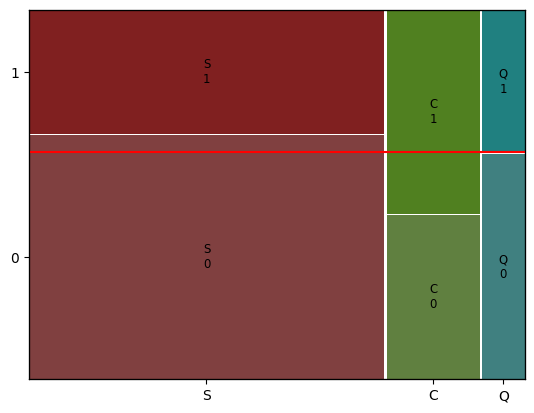

In [21]:
mosaic(titanic, ['Embarked', 'Survived'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-titanic['Survived'].mean(), color='r')    # 전체 

plt.show()
                

Survived         0         1
Embarked                    
C         0.446429  0.553571
Q         0.610390  0.389610
S         0.663043  0.336957
------------------------------


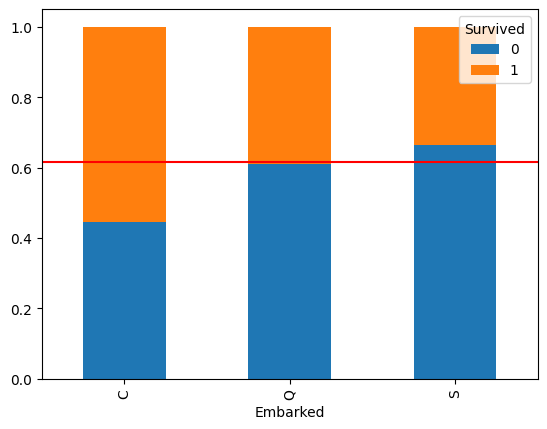

In [22]:
temp = pd.crosstab(titanic['Embarked'], titanic['Survived'], normalize='index')
print(temp)
print('-'*30)

temp.plot.bar(stacked=True)
plt.axhline(1-titanic['Survived'].mean(), color='r')
plt.show()

[문3] Title --> Survived

In [23]:
pd.crosstab(titanic['Title'], titanic['Sex'], normalize = 'columns')

Sex,female,male
Title,,
Master,0.000000,0.069324
Miss,0.579618,0.000000
Mr,0.000000,0.896014
Mrs,0.398089,0.000000
Others,0.022293,0.034662


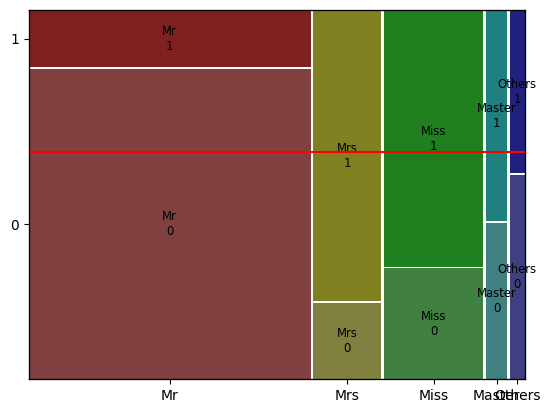

In [26]:
mosaic(titanic, ['Title', 'Survived'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-titanic['Survived'].mean(), color='r')    # 전체 
plt.show()
                

Survived         0         1
Title                       
Master    0.425000  0.575000
Miss      0.302198  0.697802
Mr        0.843327  0.156673
Mrs       0.208000  0.792000
Others    0.555556  0.444444
------------------------------


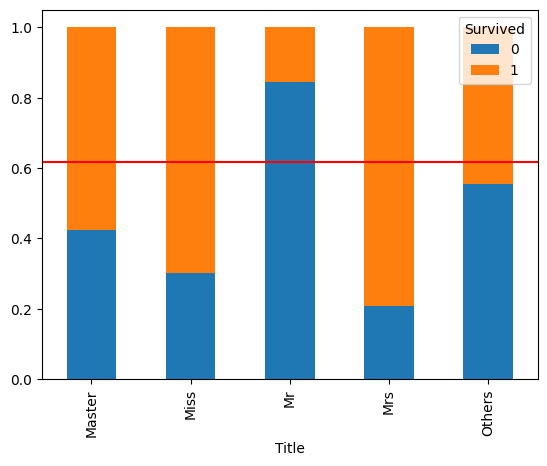

In [27]:
temp = pd.crosstab(titanic['Title'], titanic['Survived'], normalize='index')
print(temp)
print('-'*30)

temp.plot.bar(stacked=True)
plt.axhline(1-titanic['Survived'].mean(), color='r')
plt.show()

### 4.2.3. 수치화 : 카이제곱검정

* 카이제곱검정 : 범주형 변수들 사이에 어떤 관계가 있는지, 수치화 하는 방법

- 카이 제곱 통계량
    - 계산 목적: 관측값(실제 데이터)과 기대값(관계가 없다고 가정했을 때의 값)의 차이를 측정하여, 두 범주형 변수 사이에 연관성이 있는지 확인함.
    - 클수록 기대빈도로부터 실제 값에 차이가 크다는 의미.
    - 계산식으로 볼 때, 범주의 수가 늘어날 수록 값은 커지게 되어 있음.
    - 보통, 자유도의 2~3배 보다 크면, 차이가 있다고 본다.

- 범주형 변수의 자유도 : 범주의 수 - 1

- 카이제곱검정에서는
    - x 변수의 자유도 × y 변수의 자유도
    - 예 : Pclass --> Survived
        - Pclass : 범주가 3개, Survived : 2개
        - (3-1) * (2-1) = 2
        - 그러므로, 2의 2 ~ 3배인 4 ~ 6 보다 카이제곱 통계량이 크면, 차이가 있다고 볼수 있음.


- 자유도 : https://blog.minitab.com/en/statistics-and-quality-data-analysis/what-are-degrees-of-freedom-in-statistics

* 타이타닉 데이터에서 객실등급과 생존여부 간의 카이제곱 검정을 수행해 봅시다.

In [28]:
table = pd.crosstab(titanic['Survived'], titanic['Pclass'])
display(table)

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


In [ ]:
spst.chi2_contingency(table)

# output
# (카이제곱 통계량, p-value, 자유돟, 기대빈도)

# 카이제곱 통계량 : 기대빈도와 관측빈도 간의 차이를 측정한 값. 값이 클수록 두 변수 간에 연관성이 강하다는 것을 의미.
# 자유도 : Pclass 3개 범주, Survived 2개 범주 자유도 계산 => (3-1) * (2-1) = 2. (행-1)*(열-1) = 자유도

# 해석
# p-value : 매우 작아 귀무가설(두 변수는 독립이다.)을 기각.
# 즉, 객실 등급과 생존 여부는 독립적이지 않고 서로 연관성이 있다.

Chi2ContingencyResult(statistic=np.float64(102.88898875696056), pvalue=np.float64(4.549251711298793e-23), dof=2, expected_freq=array([[133.09090909, 113.37373737, 302.53535354],
       [ 82.90909091,  70.62626263, 188.46464646]]))

**<연습문제>**

다음의 관계에 대해 수치화 해 봅시다.

[문1] Sex --> Survived

In [31]:
table = pd.crosstab(titanic['Sex'], titanic['Survived'])
display(table)

spst.chi2_contingency(table)

Survived,0,1
Sex,,
female,81,233
male,468,109


Chi2ContingencyResult(statistic=np.float64(260.71702016732104), pvalue=np.float64(1.1973570627755645e-58), dof=1, expected_freq=array([[193.47474747, 120.52525253],
       [355.52525253, 221.47474747]]))

[문2] Embarked --> Survived

In [32]:
table = pd.crosstab(titanic['Embarked'], titanic['Survived'])
display(table)

spst.chi2_contingency(table)

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


Chi2ContingencyResult(statistic=np.float64(26.48914983923762), pvalue=np.float64(1.769922284120912e-06), dof=2, expected_freq=array([[103.7480315,  64.2519685],
       [ 47.5511811,  29.4488189],
       [397.7007874, 246.2992126]]))

[문3] Title --> Survived

In [33]:
table = pd.crosstab(titanic['Title'], titanic['Survived'])
display(table)

spst.chi2_contingency(table)

Survived,0,1
Title,,
Master,17,23
Miss,55,127
Mr,436,81
Mrs,26,99
Others,15,12


Chi2ContingencyResult(statistic=np.float64(283.3115089621979), pvalue=np.float64(4.305036064730923e-60), dof=4, expected_freq=array([[ 24.64646465,  15.35353535],
       [112.14141414,  69.85858586],
       [318.55555556, 198.44444444],
       [ 77.02020202,  47.97979798],
       [ 16.63636364,  10.36363636]]))

## 4.3.숫자 --> 범주

### 4.3.1. 시각화

- 시각화 : kde Plot, Histogram
    - 범주별 **분포**로 비교하는 그래프 그리기
    - 범주별 **비율**로 비교하는 그래프 그리기

* 히스토그램을 Survived로 나눠서 그려봅시다.

In [ ]:
sns.histplot(x='Age',y='Survived',data=)
plt.show() ??

- kdeplot을 그리는 두 가지 방법이 있다.
    - ① kdeplot(   , hue = 'Survived')
        - 생존여부의 비율이 유지된 채로 그려짐
        - 두 그래프의 아래 면적의 합이 1
    - ② kdeplot(   , hue = 'Survived', common_norm = False)
        - 생존여부 각각 아래 면적의 합이 1인 그래프
    - ③ kdeplot(   , hue = 'Survived', multiple = 'fill')
        - 나이에 따라 생존여부 **비율**을 비교해볼 수 있음. (양의 비교가 아닌 비율!)


① kdeplot( , hue = 'Survived)
- common_norm = True (기본값)
    - common_norm: 그래프 안쪽 넓이가 True면 합쳐서 1, 아니면 각각 넓이가 1

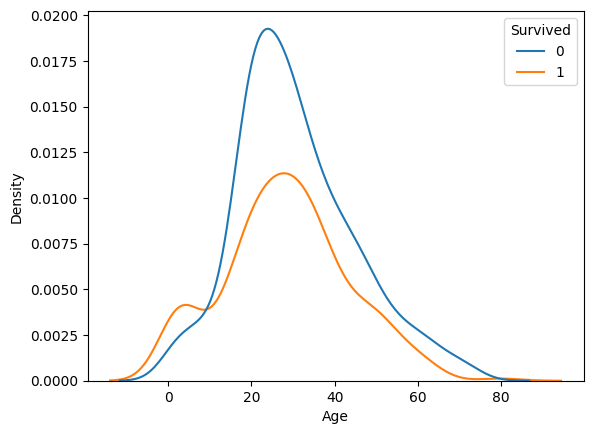

In [34]:
sns.kdeplot(x='Age', data=titanic, hue='Survived')
plt.show()

② kdeplot( , hue = 'Survived, common_norm = False)

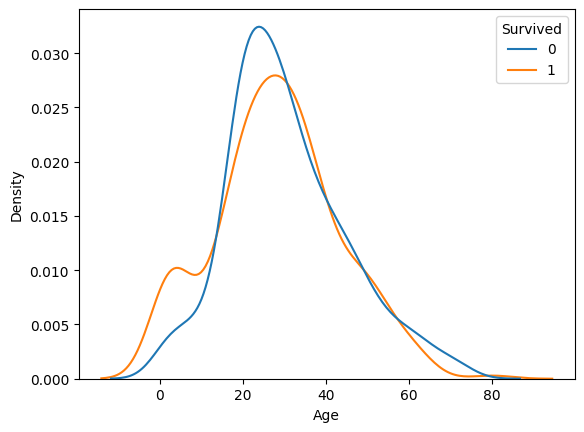

In [ ]:
sns.kdeplot(x='Age', data=titanic, hue='Survived', common_norm=False)
plt.show() # 각 사망자, 생존자 집단의 나이 비율을 볼 수 있음

③ multiple = 'fill' 옵션

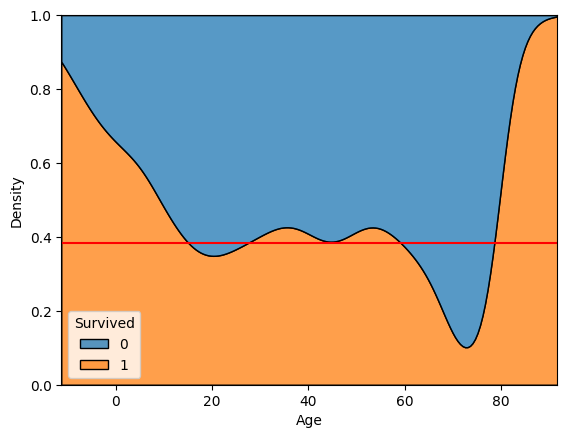

In [37]:
sns.kdeplot(x='Age', data=titanic, hue='Survived', multiple='fill')

plt.axhline(titanic['Survived'].mean(), color='r')
plt.show()

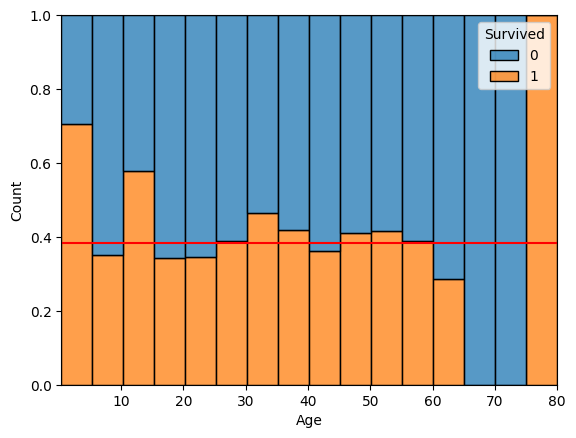

In [38]:
sns.histplot(x='Age', data=titanic, hue='Survived', bins=16, multiple='fill')

plt.axhline(titanic['Survived'].mean(), color='r')
plt.show()

- 나이에 따라서 생존여부가
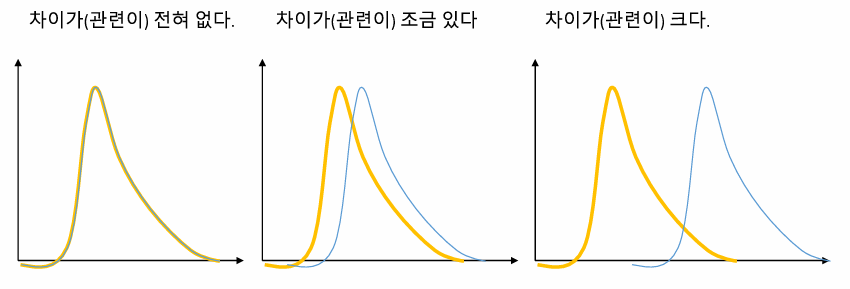

**<연습문제>**

다음의 관계에 대해 시각화 해 봅시다.

* [문1] Fare(운임) --> Survived